# 04_4 – Hough vonalak detektálása

Izolált teszt: HoughLinesP a maszkolt él-képen.

**Cél:** Látni, hogy a maszkolt edge-map-ből mennyi és milyen vonalat detektál a Hough-transzformáció. Ha túl kevés vonal jön ki → a split és outer_edges fázisok megbuknak.

**Ha itt hiba van:** Kevés Hough-vonal → `no_long_lines` hiba vagy hibás trapéz.

## 1. Imports, útvonalak, konstansok

A `v13`/`03c` importokat és konstansokat használjuk, változtatás nélkül.

In [ ]:
from __future__ import annotations

import math
import os
import warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False

try:
    import cv2
    CV2_AVAILABLE = True
    print(f"cv2 elérhető: {cv2.__version__}")
except Exception:
    cv2 = None
    CV2_AVAILABLE = False
    print("⚠️  cv2 NEM elérhető – a legtöbb lépés kihagyódik.")

try:
    import mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision
    MEDIAPIPE_AVAILABLE = True
    print("mediapipe elérhető")
except Exception:
    mp = mp_python = mp_vision = None
    MEDIAPIPE_AVAILABLE = False
    print("⚠️  mediapipe NEM elérhető – kézdetektálás kihagyható.")

# ── Import dari src modules ──────────────────────────────────────────────────
from src.hand_landmark import build_finger_mask, anchor_neck_angle, FINGER_CHAINS, FINGER_THICK_MULT
from src.geometry import step1_canny, step2_hough, step3_neck_angle, step3_neck_angle_anchored

# ── Projekt útvonalak ─────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT     = PROJECT_ROOT / "data"
NOTEBOOK_DIR  = PROJECT_ROOT / "notebooks"
MODEL_DIR     = PROJECT_ROOT / "models"
MANIFEST_PATH = DATA_ROOT / "split_manifest.csv"
OUTPUT_DIR    = PROJECT_ROOT / "output" / "03b_pipeline_debug"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Geometriai konstansok ──────────────────────────────────────────────────
CANONICAL_W   = 600          # kanonikus tér szélessége (px)
CANONICAL_H   = 80           # kanonikus tér magassága (px)
N_FRETS       = 24
FRET_RULE     = 17.817

# Bund n x-pozíciója ha a teljes nyak kitölti a kanonikus teret [0..N_FRETS]
# x_n = CANONICAL_W * (1 - 0.5^(n/12)) / 0.75
FRET_POS_FULL = np.array(
    [CANONICAL_W * (1.0 - 0.5 ** (n / 12.0)) / 0.75 for n in range(N_FRETS + 1)],
    dtype=np.float64,
)
# Normalizált pozíciók (0..1, ahol 1.0 = a 24. bund pozíciója)
FRET_POS_NORM = np.array(
    [1.0 - 0.5 ** (n / 12.0) for n in range(N_FRETS + 1)],
    dtype=np.float64,
)

FINGER_TIP_IDX = [4, 8, 12, 16, 20]   # MediaPipe ujjhegy landmark indexek
INLAY_FRETS    = [3, 5, 7, 9, 12]     # Standard 5 inlay pozíció
INLAY_FRETS_FULL = [3, 5, 7, 9, 12, 15, 17, 19, 21, 24]  # Mindkét oktáv

# Inlay normalizált x-pozíciók: az n. inlay a FRET_POS_NORM[n-1] és [n] közötti tér közepe
INLAY_NORM_DICT = {
    n: (FRET_POS_NORM[n - 1] + FRET_POS_NORM[n]) / 2.0
    for n in INLAY_FRETS_FULL
}

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUTPUT_DIR}")
print(f"FRET_POS_FULL[:7] = {np.round(FRET_POS_FULL[:7], 1)}")

cv2 elérhető: 4.13.0
mediapipe elérhető
Project root : /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition
Output dir   : /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/03b_pipeline_debug
FRET_POS_FULL[:7] = [  0.   44.9  87.3 127.3 165.  200.7 234.3]


## 2. Seed-ek beállítása — HIBA 2 keret-rendszer

`FIXED_SEEDS = [42, 43]` rögzített, a másik **8 seed** futásonként random
(`np.random.default_rng()` belső állapotából). A teljes lista kiírásra kerül,
hogy ha valami furcsa eredmény jön, azt egy fix seedlistával reprodukálni lehessen.


In [13]:
# HIBA 2: 10 kép – 2 fix + 8 random seed
FIXED_SEEDS = [42, 43]
_seed_rng   = np.random.default_rng()   # nincs seed → futásonként más
RANDOM_SEEDS = [int(_seed_rng.integers(0, 1_000_000)) for _ in range(8)]
ALL_SEEDS    = FIXED_SEEDS + RANDOM_SEEDS
print("ALL_SEEDS (notebook tetején):", ALL_SEEDS)


ALL_SEEDS (notebook tetején): [42, 43, 170457, 598743, 462772, 23255, 2224, 253289, 655867, 962038]


## 3. 10 kép mintavételezése a manifest-ből

A `data/split_manifest.csv` "train" split-jéből minden seed-hez 1 random képet
veszünk (`pandas.DataFrame.sample(n=1, random_state=seed)`). Így a fix seed-ek
ugyanazt a 2 képet adják minden futáskor, a 8 random pedig más-más képet.


In [14]:
# Manifest betöltés + helper függvények (v13 cell 4 alapján, módosítva)
manifest = pd.read_csv(MANIFEST_PATH)
CLASSES  = sorted(manifest["class"].unique())
print(f"Összes kép: {len(manifest)}, osztályok: {CLASSES}")

def load_image_bgr(img_path: str):
    """BGR kép betöltése (cv2 elsődleges, PIL fallback)."""
    if CV2_AVAILABLE:
        img = cv2.imread(str(img_path))
        if img is not None:
            return img
    if PIL_AVAILABLE:
        arr = np.array(Image.open(img_path).convert("RGB"))
        return arr[:, :, ::-1].copy()
    return None

def bgr2rgb(img_bgr):
    if CV2_AVAILABLE:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr[:, :, ::-1]

# Seedenként 1 random train-kép
train_pool = manifest[manifest["split"] == "train"].reset_index(drop=True)
IMAGES = []
for s in ALL_SEEDS:
    row = train_pool.sample(n=1, random_state=s).iloc[0]
    IMAGES.append({
        "seed":  s,
        "path":  str(row["path"]),
        "class": row["class"],
        "fname": Path(row["path"]).name,
    })

for img in IMAGES:
    print(f"  seed={img['seed']:>6}  class={img['class']}  file={img['fname']}")


Összes kép: 297, osztályok: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']
  seed=    42  class=F  file=1762212514026.jpg
  seed=    43  class=B  file=IMG_20251102_024334.jpg
  seed=170457  class=G  file=1762212558182.jpg
  seed=598743  class=A  file=1762212326293.jpg
  seed=462772  class=C  file=IMG_20251102_024036.jpg
  seed= 23255  class=C  file=1762212395208.jpg
  seed=  2224  class=B  file=1762212364206.jpg
  seed=253289  class=E  file=1762212477984.jpg
  seed=655867  class=B  file=IMG_20251102_024331.jpg
  seed=962038  class=No hand  file=IMG_20251102_023815.jpg


## 2. MediaPipe model inicializálás

A `hand_landmarker.task` modell betöltése. Ha nem létezik, automatikusan letölti.

In [15]:
# MediaPipe model inicializálás
HAND_LANDMARKER = None
if MEDIAPIPE_AVAILABLE:
    model_path = MODEL_DIR / "hand_landmarker.task"
    if not model_path.exists():
        import urllib.request
        model_path.parent.mkdir(parents=True, exist_ok=True)
        MODEL_URL = (
            "https://storage.googleapis.com/mediapipe-models/"
            "hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
        )
        print(f"MediaPipe model letöltése: {MODEL_URL}")
        urllib.request.urlretrieve(MODEL_URL, model_path)
    try:
        opts = mp_vision.HandLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=str(model_path)),
            running_mode=mp_vision.RunningMode.IMAGE,
            num_hands=2,
        )
        HAND_LANDMARKER = mp_vision.HandLandmarker.create_from_options(opts)
        print("✅ HandLandmarker inicializálva.")
    except Exception as exc:
        print(f"⚠️  HandLandmarker hiba: {exc}")


def step9_detect_landmarks(img_path: str, landmarker=None):
    """MediaPipe kéz landmark detektálás. Visszaad: [(x_norm,y_norm,z_norm)]*21 vagy None."""
    if landmarker is None or not MEDIAPIPE_AVAILABLE:
        return None
    try:
        image  = mp.Image.create_from_file(str(img_path))
        result = landmarker.detect(image)
        if not result.hand_landmarks:
            return None
        best = result.hand_landmarks[0]
        return [(float(lm.x), float(lm.y), float(lm.z)) for lm in best]
    except Exception as exc:
        print(f"  [mediapipe] hiba: {exc}")
        return None


def step9_project_fingertips(landmarks, H: np.ndarray,
                             w_img: int, h_img: int,
                             fit: dict = None) -> list[dict]:
    """
    21 MediaPipe landmark → kanonikus tér vetítés.

    Visszaad: lista dict-ekből, minden ujjhegyhez:
        tip_idx       : int – MediaPipe index (4,8,12,16,20)
        canon_x, canon_y : float – kanonikus px
        string_norm   : float 0–1 – húr pozíció
        fret_est      : int|None – legközelebbi illesztett bund
    """
    if landmarks is None or H is None:
        return []
    results = []
    pred = fit.get("predicted_x", {}) if fit else {}
    for tip_idx in FINGER_TIP_IDX:
        if tip_idx >= len(landmarks):
            continue
        xn, yn, _ = landmarks[tip_idx]
        px, py    = xn * w_img, yn * h_img
        pt        = np.array([px, py, 1.0])
        proj      = H @ pt
        if abs(proj[2]) < 1e-9:
            continue
        cx = float(proj[0] / proj[2])
        cy = float(proj[1] / proj[2])
        str_norm  = float(np.clip(cy / CANONICAL_H, 0.0, 1.0))
        fret_est  = None
        if pred:
            fret_est = min(pred.keys(), key=lambda n: abs(pred[n] - cx))
        results.append({
            "tip_idx":   tip_idx,
            "canon_x":   cx,
            "canon_y":   cy,
            "string_norm": str_norm,
            "fret_est":  fret_est,
        })
    return results


def viz_fingertips_canonical(canon_bgr: np.ndarray, tips: list[dict],
                              fit: dict = None) -> None:
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.imshow(bgr2rgb(canon_bgr), aspect="auto")
    if fit:
        for n, x in fit.get("predicted_x", {}).items():
            if 0 <= x <= CANONICAL_W:
                ax.axvline(x, color="lime", lw=0.6, alpha=0.4, linestyle=":")
                ax.text(x, 3, str(n), color="lime", fontsize=6,
                        ha="center", va="top")
    colors = ["#FF6B6B","#FFD93D","#6BCB77","#4D96FF","#F4A261"]
    finger_names = {4:"Hüvelyk",8:"Mutató",12:"Középső",16:"Gyűrűs",20:"Kisujj"}
    for tip, col in zip(tips, colors):
        if -5 <= tip["canon_x"] <= CANONICAL_W+5 and 0 <= tip["canon_y"] <= CANONICAL_H:
            ax.plot(tip["canon_x"], tip["canon_y"], "o", color=col, ms=10,
                    zorder=6, label=f"{finger_names.get(tip['tip_idx'],tip['tip_idx'])} → bund {tip['fret_est']}")
    ax.legend(loc="lower right", fontsize=8, ncol=2)
    ax.set_title("STEP 9: Ujjhegyek a kanonikus térben")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def viz_overlay_original(img_bgr: np.ndarray, corners: np.ndarray,
                         H_inv: np.ndarray, tips: list[dict],
                         fit: dict, landmarks) -> None:
    """Teljes overlay az eredeti képen: trapéz + bund-vonalak visszavetítve + ujjhegyek."""
    if not CV2_AVAILABLE:
        return
    overlay = bgr2rgb(img_bgr).copy()
    h_img, w_img = img_bgr.shape[:2]
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.imshow(overlay)
    # Trapezoid
    loop = np.vstack([corners, corners[0]])
    ax.plot(loop[:,0], loop[:,1], color="orange", lw=2.5, label="Trapezoid")
    # Bund vonalak visszavetítve a képtérbe
    for n, x_c in fit.get("predicted_x", {}).items():
        if not (0 <= x_c <= CANONICAL_W):
            continue
        top_c    = np.array([x_c, 0.0, 1.0])
        bot_c    = np.array([x_c, float(CANONICAL_H), 1.0])
        top_orig = H_inv @ top_c
        bot_orig = H_inv @ bot_c
        if abs(top_orig[2]) < 1e-9 or abs(bot_orig[2]) < 1e-9:
            continue
        tx, ty = top_orig[0]/top_orig[2], top_orig[1]/top_orig[2]
        bx, by = bot_orig[0]/bot_orig[2], bot_orig[1]/bot_orig[2]
        col = "yellow" if n in INLAY_FRETS else "cyan"
        ax.plot([tx,bx],[ty,by], color=col, lw=0.8, alpha=0.7)
        ax.text(tx, ty-5, str(n), color=col, fontsize=7, ha="center")
    # MediaPipe ujjhegyek (ha van)
    if landmarks:
        colors = ["#FF6B6B","#FFD93D","#6BCB77","#4D96FF","#F4A261"]
        for tip, col in zip(tips, colors):
            xi = tip["canon_x"]
            yi = tip["canon_y"]
            pt_c = np.array([xi, yi, 1.0])
            pt_o = H_inv @ pt_c
            if abs(pt_o[2]) < 1e-9:
                continue
            px, py = pt_o[0]/pt_o[2], pt_o[1]/pt_o[2]
            ax.plot(px, py, "o", color=col, ms=12, zorder=7,
                    label=f"ujj→bund {tip['fret_est']}")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title("STEP 9 overlay: Visszavetített bundok + ujjhegyek")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


✅ HandLandmarker inicializálva.


I0000 00:00:1779060691.233846 2305738 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779060691.235602 2305750 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1779060691.250233 2305742 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779060691.263853 2305744 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 2. Függvények

## 5. Új helper függvények — HIBA 1 és HIBA 3 javítás

### 5.1 `build_finger_mask` — HIBA 1A

MediaPipe 21 landmarkjából a 4 ujj (mutató, középső, gyűrűs, kisujj) és a
hüvelykujj szegmenseihez vastag vonalakat rajzol egy `uint8` maszkra. A
szegmens-vastagság a szegmens hosszának 18–22%-a (gitár-ujj arány), a hüvelyk
kicsit vastagabb. A maszkot a Canny edge map-re `& ~mask` formában alkalmazzuk
a `run_v14_pipeline`-ban, így a Hough nem lát ujj-éleket.


### 5.2 `anchor_neck_angle` — HIBA 3A

A landmark-okból (csukló = 0, középső-MCP = 9, mutató-MCP = 5, gyűrűs-MCP = 13)
becsüljük a kéz fő tengelyét és a tenyér centroidját. A gitárnyak iránya közel
**merőleges** erre a kéztengelyre, így ez egy erős prior a step3 hisztogramra:
`expected_neck_angle ± 25°` ablakon belüli legerősebb csúcsot vesszük.


In [ ]:
def viz_canny(img_bgr: np.ndarray, edges: np.ndarray,
              title_suffix: str = "") -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(bgr2rgb(img_bgr))
    axes[0].set_title("Eredeti kép")
    axes[0].axis("off")
    axes[1].imshow(edges, cmap="gray")
    axes[1].set_title(f"Canny élkép {title_suffix}")
    axes[1].axis("off")
    plt.suptitle("STEP 1: Canny éldetektálás", fontweight="bold")
    plt.tight_layout()
    plt.show()

### step2_hough

HoughLinesP paraméterek: `threshold=30, min_len_frac=0.15, max_gap=15`.

## 3. Futtatás – 10 kép

In [20]:
# ── Futtatás: Hough vonalak 10 képen ─────────────────────────────────────
RESULTS = []
for entry in IMAGES:
    img = load_image_bgr(entry["path"])
    if img is None:
        RESULTS.append({"seed": entry["seed"], "class": entry["class"],
                         "fname": entry["fname"], "ok": False}); continue
    lms    = step9_detect_landmarks(entry["path"], HAND_LANDMARKER)
    anchor = anchor_neck_angle(lms, img.shape)
    mask   = build_finger_mask(img.shape, lms)
    edges  = step1_canny(img)
    edges_masked = edges.copy()
    if mask.any():
        edges_masked[mask > 0] = 0
    lines  = step2_hough(img, edges_masked)
    RESULTS.append({
        "seed": entry["seed"], "class": entry["class"],
        "fname": entry["fname"], "ok": bool(lines),
        "img": img, "landmarks": lms, "anchor": anchor,
        "finger_mask": mask, "edges_masked": edges_masked, "lines": lines,
    })
    print(f"  seed={entry['seed']} | {entry['class']} | "
          f"Hough: {len(lines)} vonal")
print(f"\nKész. Következik a vonalak vizualizációja.")


  seed=42 | F | Hough: 9 vonal
  seed=43 | B | Hough: 6 vonal
  seed=170457 | G | Hough: 7 vonal
  seed=598743 | A | Hough: 8 vonal
  seed=462772 | C | Hough: 7 vonal
  seed=23255 | C | Hough: 4 vonal
  seed=2224 | B | Hough: 8 vonal
  seed=253289 | E | Hough: 11 vonal
  seed=655867 | B | Hough: 10 vonal
  seed=962038 | No hand | Hough: 11 vonal

Kész. Következik a vonalak vizualizációja.


## 4. Vizualizáció: Hough vonalak (narancssárga)

In [21]:
def _phase_grid(title: str, draw_fn, figsize=(20, 8)):
    """Általános 2×5 grid 10 RESULTS bejegyzéssel.

    draw_fn(ax, result) – egy subplot kirajzolása. Ha a result['ok']=False ÉS a
    fázis amit rajzolunk csak ok eseten értelmezhető, akkor a draw_fn-nek
    kezelnie kell a hiányzó kulcsokat. Az INVALID overlay-t a wrapper rakja rá.
    """
    fig, axes = plt.subplots(2, 5, figsize=figsize)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    for ax, r in zip(axes.ravel(), RESULTS):
        try:
            draw_fn(ax, r)
        except Exception as exc:
            ax.text(0.5, 0.5, f"draw error:\n{exc}", ha="center", va="center",
                    transform=ax.transAxes, color="red", fontsize=8)
        sub_title = f"seed={r['seed']} | {r['class']} | {r['fname'][:14]}"
        ax.set_title(sub_title, fontsize=8)
        ax.axis("off")
        if r.get("invalid_reason"):
            ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, fill=False,
                                        edgecolor="red", lw=2.5,
                                        transform=ax.transAxes))
            ax.text(0.5, 0.94, "INVALID", color="red", fontsize=11,
                    fontweight="bold", ha="center", va="top",
                    transform=ax.transAxes,
                    bbox=dict(facecolor="white", alpha=0.8, pad=2,
                              edgecolor="red"))
    plt.tight_layout()
    plt.show()


def _maybe_imshow(ax, img):
    if img is not None:
        ax.imshow(img)


### 7.2 Hough vonalak (maszkolás után)

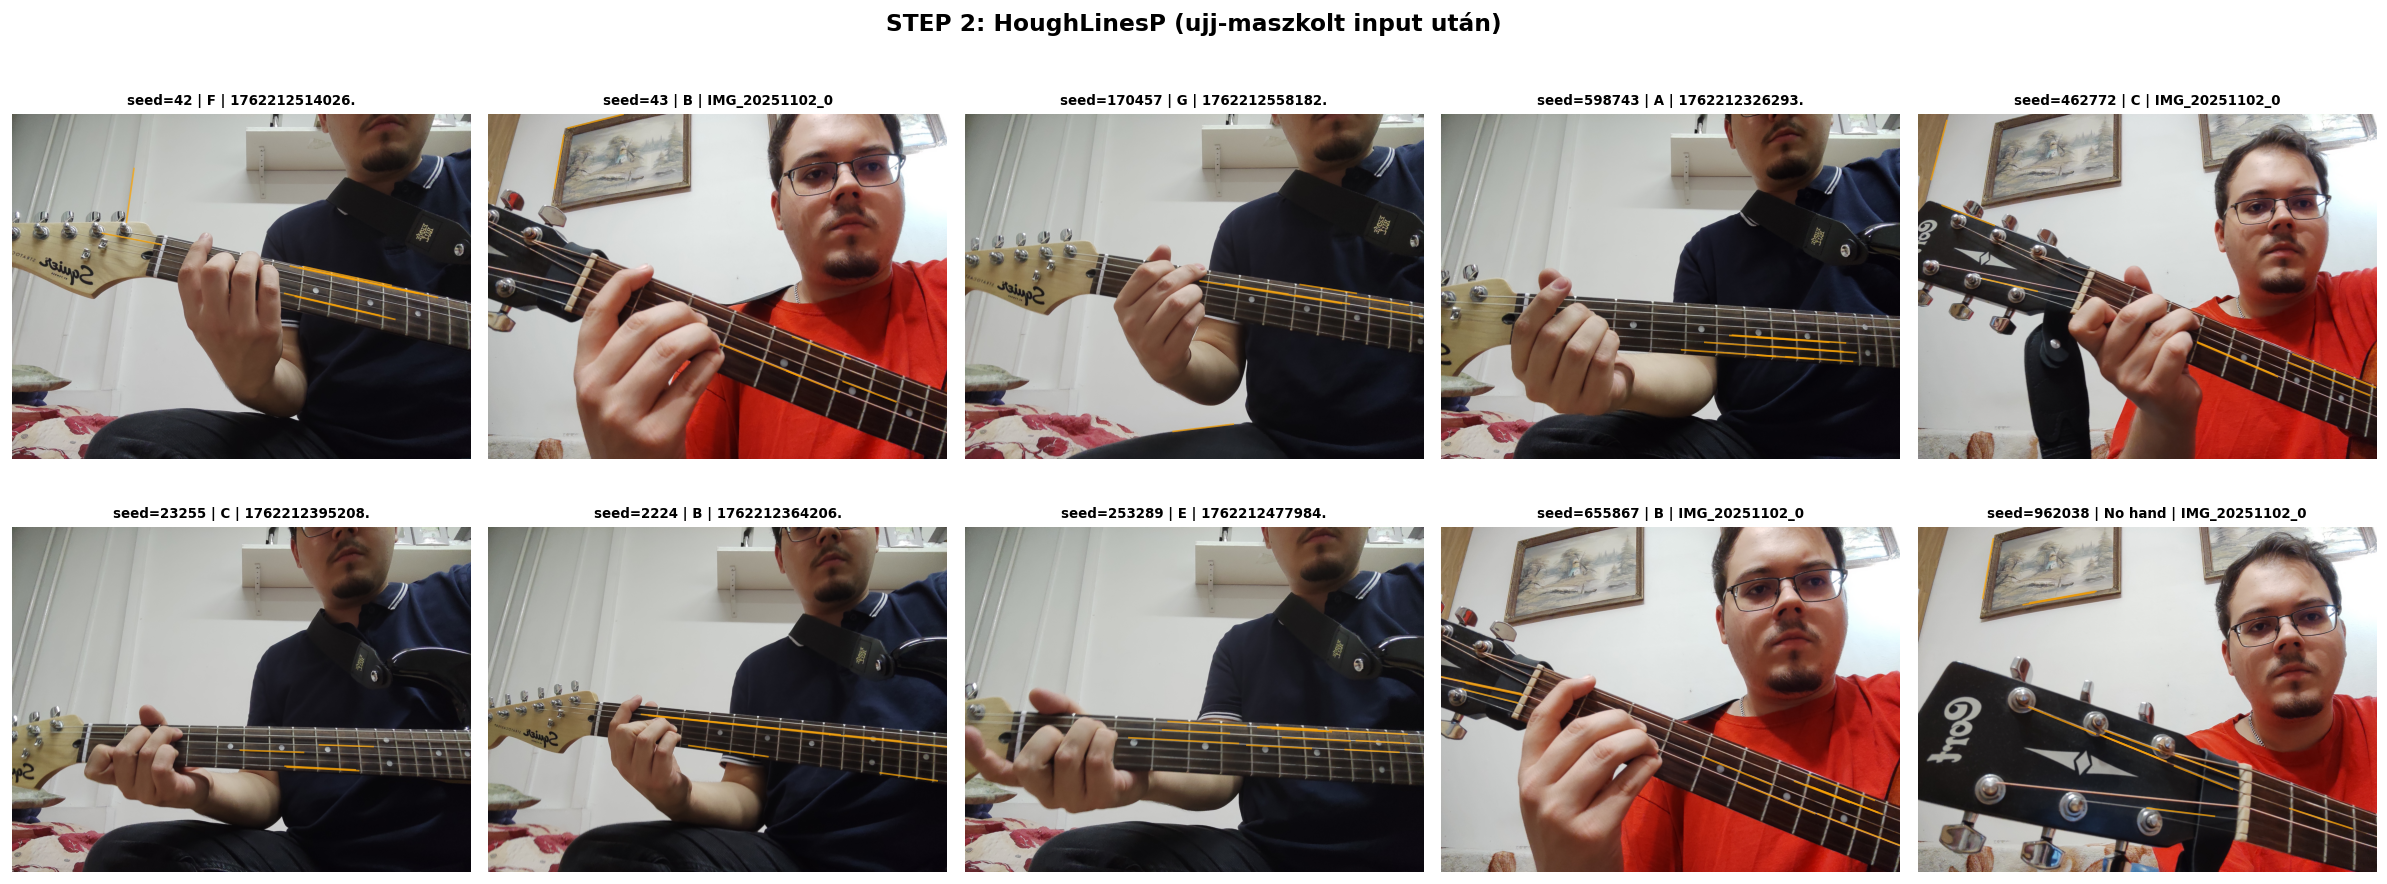

In [22]:
def _draw_hough(ax, r):
    img = r.get("img")
    if img is None:
        return
    ax.imshow(bgr2rgb(img))
    for (x1, y1, x2, y2) in r.get("lines", []) or []:
        ax.plot([x1, x2], [y1, y2], color="orange", lw=1.0, alpha=0.7)

_phase_grid("STEP 2: HoughLinesP (ujj-maszkolt input után)", _draw_hough)


## 5. Statisztika: vonal-számok

Hány vonalat ad a Hough minden képen? < 3 vonal → szinte biztos pipeline-bukás.

In [23]:
print(f"{'seed':>8} {'class':<8} {'#vonalak':>10}")
print("-" * 30)
for r in RESULTS:
    print(f"{r['seed']:>8} {r['class']:<8} {len(r.get('lines') or []):>10}")


    seed class      #vonalak
------------------------------
      42 F                 9
      43 B                 6
  170457 G                 7
  598743 A                 8
  462772 C                 7
   23255 C                 4
    2224 B                 8
  253289 E                11
  655867 B                10
  962038 No hand          11
